In [6]:
# CREDIT RISK PREDICTION PROJECT
# Hari Prasaad — Year 1 CS Student
# ============================================================

# ============================================================
# SECTION 1 — IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# SECTION 2 — LOAD DATA
# ============================================================

path = kagglehub.dataset_download("benjaminmcgregor/german-credit-data-set-with-credit-risk")
df = pd.read_csv(os.path.join(path, 'german_credit_data_updated.csv'))

print("Shape:", df.shape)
print(df.head())

# ============================================================
# SECTION 3 — DATA CLEANING
# ============================================================

# Drop the unnamed row index column
df = df.drop(columns=['Unnamed: 0'])

# Fill missing Checking account values with 'Unknown'
df.loc[df['Checking account'].isna(), 'Checking account'] = 'Unknown'

# Drop rows where Saving accounts is missing
df = df.dropna(subset=['Saving accounts'])

# Capitalise text columns consistently
df['Checking account'] = df['Checking account'].str.title()
df['Saving accounts'] = df['Saving accounts'].str.title()
df['Purpose'] = df['Purpose'].str.title()
df['Sex'] = df['Sex'].str.title()
df['Housing'] = df['Housing'].str.title()

# Encode target — 1 = High Risk, 2 = Low Risk (original dataset encoding)
df['Credit Risk'] = df['Credit Risk'].apply(lambda x: 'High' if x == 1 else 'Low')

print("\nData cleaned successfully")
print(df['Credit Risk'].value_counts())

# Save a clean copy before any encoding
df_original = df.copy()

Using Colab cache for faster access to the 'german-credit-data-set-with-credit-risk' dataset.
Shape: (954, 11)
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  Credit Risk  
0           1169         6             radio/TV            1  
1           5951        48             radio/TV            2  
2           2096        12            education            1  
3           7882        42  furniture/equipment            1  
4           4870        24                  car            2  

Data cleaned successfully
Credit Risk
High    522
Low

In [7]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
1,22,Female,2,Own,Little,Moderate,5951,48,Radio/Tv,Low
2,49,Male,1,Own,Little,Unknown,2096,12,Education,High
3,45,Male,2,Free,Little,Little,7882,42,Furniture/Equipment,High
4,53,Male,2,Free,Little,Little,4870,24,Car,Low
6,53,Male,2,Own,Quite Rich,Unknown,2835,24,Furniture/Equipment,High
...,...,...,...,...,...,...,...,...,...,...
949,31,Male,2,Own,Moderate,Unknown,3621,24,Radio/Tv,Low
950,40,Male,0,Own,Little,Moderate,3590,18,Business,High
951,24,Male,2,Own,Little,Little,2145,36,Business,Low
952,28,Female,2,Rent,Quite Rich,Moderate,4113,24,Car,Low



Average Credit Amount by Risk:
Credit Risk
0    3880.673152
1    2763.367816
Name: Credit amount, dtype: float64

Average Duration by Risk:
Credit Risk
0    24.785992
1    18.151341
Name: Duration, dtype: float64

Average Age by Risk:
Credit Risk
0    33.867704
1    35.636015
Name: Age, dtype: float64


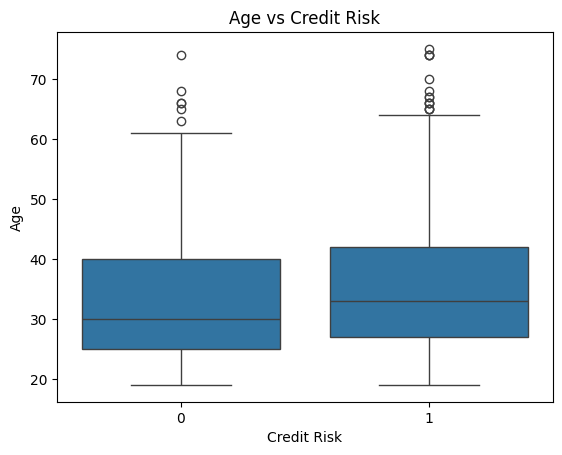

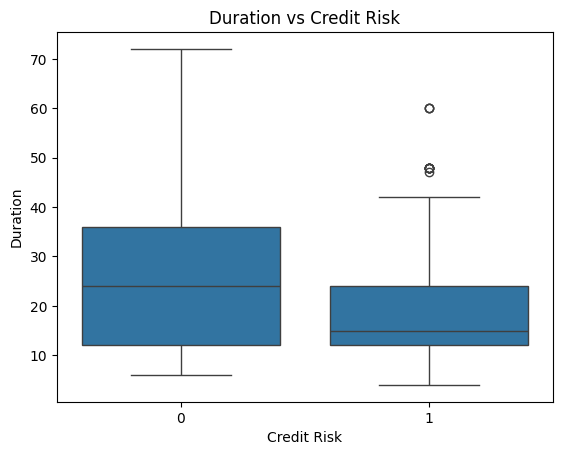

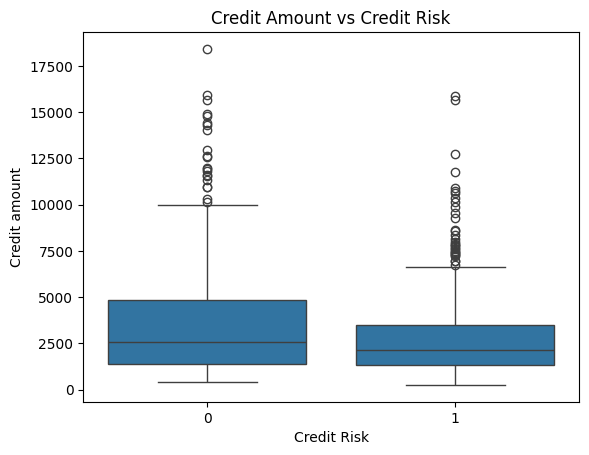

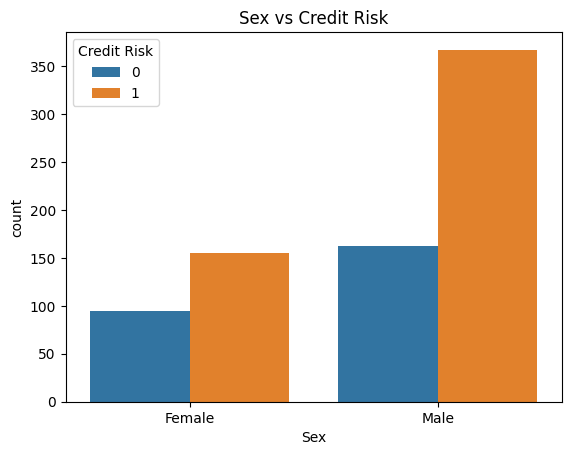

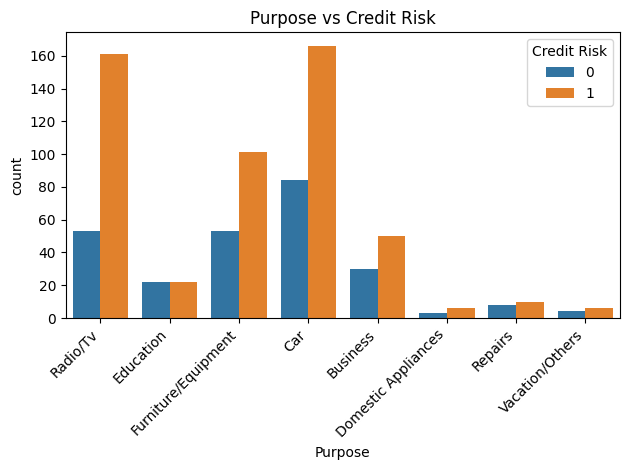

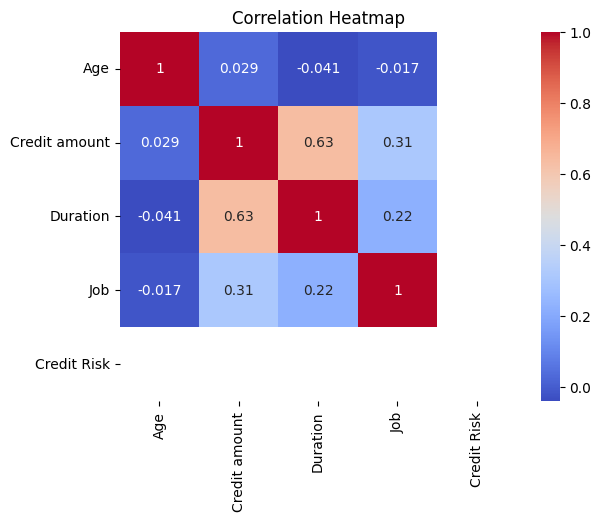

In [18]:
# ============================================================
# SECTION 4 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Groupby analysis
print("\nAverage Credit Amount by Risk:")
print(df.groupby('Credit Risk')['Credit amount'].mean())

print("\nAverage Duration by Risk:")
print(df.groupby('Credit Risk')['Duration'].mean())

print("\nAverage Age by Risk:")
print(df.groupby('Credit Risk')['Age'].mean())

# Age vs Credit Risk
sns.boxplot(x='Credit Risk', y='Age', data=df)
plt.title('Age vs Credit Risk')
plt.savefig('age_vs_risk.png', bbox_inches='tight')
plt.show()

# Duration vs Credit Risk
sns.boxplot(x='Credit Risk', y='Duration', data=df)
plt.title('Duration vs Credit Risk')
plt.savefig('duration_vs_risk.png', bbox_inches='tight')
plt.show()

# Credit Amount vs Credit Risk
sns.boxplot(x='Credit Risk', y='Credit amount', data=df)
plt.title('Credit Amount vs Credit Risk')
plt.savefig('credit_amount_vs_risk.png', bbox_inches='tight')
plt.show()

# Sex vs Credit Risk
sns.countplot(x='Sex', hue='Credit Risk', data=df)
plt.title('Sex vs Credit Risk')
plt.show()

# Purpose vs Credit Risk
sns.countplot(x='Purpose', hue='Credit Risk', data=df)
plt.title('Purpose vs Credit Risk')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Correlation heatmap — numeric columns only
numeric_df = df[['Age', 'Credit amount', 'Duration', 'Job']].copy()
numeric_df['Credit Risk'] = df['Credit Risk'].map({'Low': 0, 'High': 1})

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

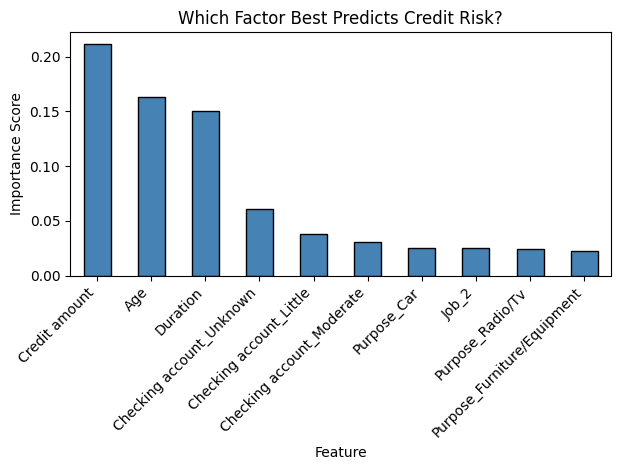


Insight: Credit amount, Age and Duration are the three strongest predictors
of credit risk, together accounting for over 54% of the model's predictive power.
This aligns with real world banking logic — larger loans over longer periods
from older borrowers on fixed incomes represent the highest default risk.


In [10]:
# ============================================================
# SECTION 5 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Encode for Random Forest — work on a copy


import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split
X = df.drop('Credit Risk', axis=1)
y = df['Credit Risk']

# Encode the remaining categorical columns
X = pd.get_dummies(X, columns=['Saving accounts', 'Checking account', 'Sex', 'Housing', 'Job', 'Purpose'], dtype=int)

# Encode target variable y to numerical values
y = y.map({'High': 1, 'Low': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Feature importance
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)[:10]

# Plot
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Which Factor Best Predicts Credit Risk?')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Insight
print("\nInsight: Credit amount, Age and Duration are the three strongest predictors")
print("of credit risk, together accounting for over 54% of the model's predictive power.")
print("This aligns with real world banking logic — larger loans over longer periods")
print("from older borrowers on fixed incomes represent the highest default risk.")

Accuracy: 0.6923076923076923
              precision    recall  f1-score   support

    Low Risk       0.67      0.12      0.20        51
   High Risk       0.69      0.97      0.81       105

    accuracy                           0.69       156
   macro avg       0.68      0.54      0.50       156
weighted avg       0.68      0.69      0.61       156



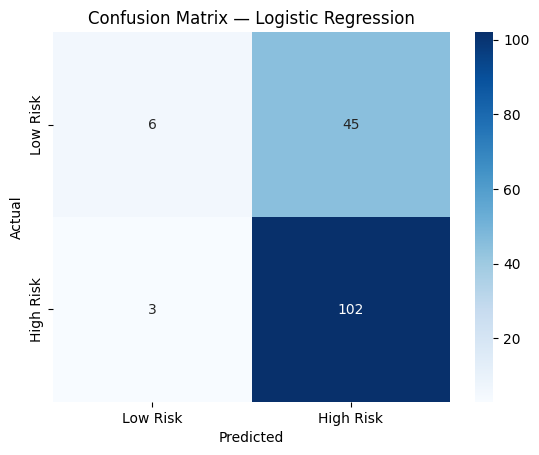

In [11]:
# Restore 'Credit Risk' from df_original to ensure it's in string format ('High', 'Low')
df['Credit Risk'] = df_original['Credit Risk']

# Encode target
df['Credit Risk'] = df['Credit Risk'].map({'Low': 0, 'High': 1})

# Independent and dependent variables
X = df[['Credit amount']]
y = df['Credit Risk']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print('Accuracy:', accuracy_score(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred,
      target_names=['Low Risk', 'High Risk']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


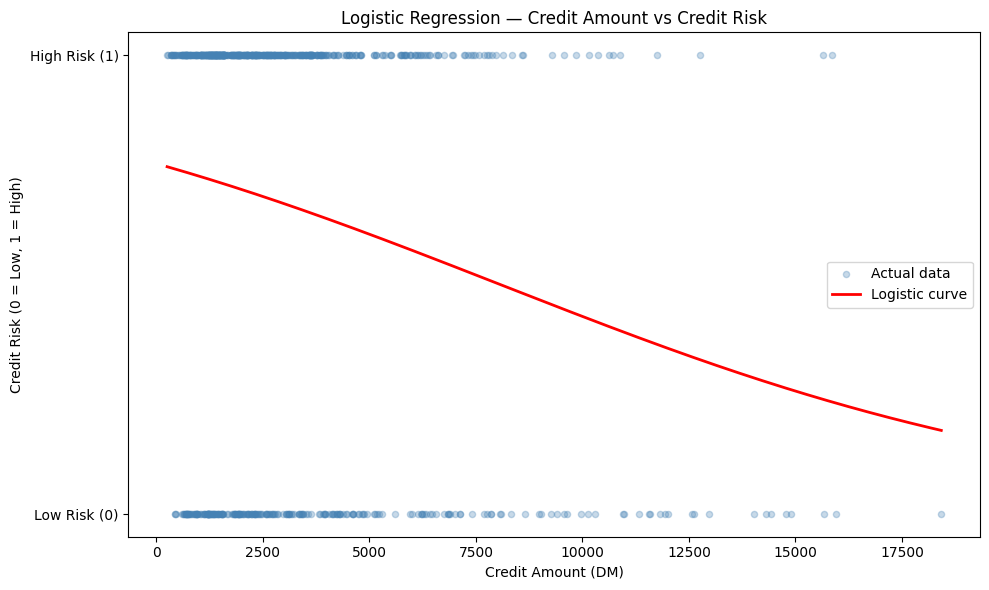

In [12]:
import numpy as np

# Generate smooth curve
X_range = np.linspace(df['Credit amount'].min(),
                      df['Credit amount'].max(), 300).reshape(-1, 1)
probs = model.predict_proba(X_range)[:, 1]

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(df['Credit amount'], df['Credit Risk'],
            alpha=0.3, color='steelblue', s=20, label='Actual data')

plt.plot(X_range, probs, color='red', linewidth=2, label='Logistic curve')

plt.xlabel('Credit Amount (DM)')
plt.ylabel('Credit Risk (0 = Low, 1 = High)')
plt.title('Logistic Regression — Credit Amount vs Credit Risk')
plt.yticks([0, 1], ['Low Risk (0)', 'High Risk (1)'])
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Prediction function
def predict_risk():
  credit_amount = int(input('Enter your credit amount in DM: '))

  input_data = [[credit_amount]]
  prediction = model.predict(input_data)[0]
  probability = model.predict_proba(input_data)[0][1]


  if prediction ==1:
    print(f"Credit Amount: {credit_amount} DM-> High Risk ({probability:.0%} probability)")
  else:
     print(f"Credit Amount: {credit_amount} DM-> Low Risk ({probability:.0%} probability)")



predict_risk()

Enter your credit amount in DM: 5000
Credit Amount: 5000 DM-> High Risk (61% probability)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [14]:
!pip install streamlit
import streamlit as st

In [16]:
import streamlit as st
import pandas as pd
import numpy as np
import os
import kagglehub
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ============================================================
# LOAD AND PREPARE DATA
# ============================================================

@st.cache_data
def load_and_train():
    path = kagglehub.dataset_download("benjaminmcgregor/german-credit-data-set-with-credit-risk")
    df = pd.read_csv(os.path.join(path, 'german_credit_data_updated.csv'))

    # Clean
    df = df.drop(columns=['Unnamed: 0'])
    df.loc[df['Checking account'].isna(), 'Checking account'] = 'Unknown'
    df = df.dropna(subset=['Saving accounts'])
    df['Credit Risk'] = df['Credit Risk'].apply(lambda x: 'High' if x == 1 else 'Low')
    df['Credit Risk'] = df['Credit Risk'].map({'Low': 0, 'High': 1})

    # Train
    X = df[['Credit amount', 'Age', 'Duration']]
    y = df['Credit Risk']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = LogisticRegression()
    model.fit(X_train, y_train)

    accuracy = accuracy_score(y_test, model.predict(X_test))

    return model, accuracy

model, accuracy = load_and_train()

# ============================================================
# UI
# ============================================================

st.title('Credit Risk Predictor')
st.write('A machine learning tool that predicts whether a borrower is a credit risk based on their loan details.')
st.write(f'Model accuracy: **{accuracy:.0%}**')

st.divider()

st.subheader('Enter your loan details')

credit_amount = st.number_input(
    'Credit Amount (DM)',
    min_value=250,
    max_value=20000,
    value=5000,
    step=250,
    help='How much money are you borrowing?'
)

age = st.number_input(
    'Age',
    min_value=18,
    max_value=75,
    value=30,
    step=1,
    help='Your current age'
)

duration = st.number_input(
    'Loan Duration (months)',
    min_value=4,
    max_value=72,
    value=24,
    step=1,
    help='How many months to repay the loan?'
)

st.divider()

if st.button('Predict My Risk', use_container_width=True):

    input_data = pd.DataFrame(
        [[credit_amount, age, duration]],
        columns=['Credit amount', 'Age', 'Duration']
    )

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    st.divider()

    if prediction == 1:
        st.error(f'High Risk — {probability:.0%} probability of default')
        st.write('Based on your details, the model predicts you are a **high risk** borrower.')
        st.write('This means a bank would likely be cautious about approving your loan.')
    else:
        st.success(f'Low Risk — {probability:.0%} probability of default')
        st.write('Based on your details, the model predicts you are a **low risk** borrower.')
        st.write('This means a bank would likely be comfortable approving your loan.')

    st.divider()

    # Show what was entered
    st.subheader('Your details')
    col1, col2, col3 = st.columns(3)
    col1.metric('Credit Amount', f'{credit_amount} DM')
    col2.metric('Age', f'{age} years')
    col3.metric('Duration', f'{duration} months')

st.divider()
st.caption('Built by Hari Prasaad — Year 1 CS Student | Trained on German Credit Dataset | Model: Logistic Regression')

2026-03-19 12:38:56.661 No runtime found, using MemoryCacheStorageManager
2026-03-19 12:38:56.667 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 12:38:56.668 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 12:38:56.669 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 12:38:56.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 12:38:56.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 12:38:56.673 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 12:38:56.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 12:38:56.675 Thread 'MainThread':

DeltaGenerator()